<a href="https://colab.research.google.com/github/pranatixsharma/fintech-system/blob/main/Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df = pd.read_csv('/content/drive/MyDrive/fintech/fraud_master_LABELLED.csv')
print(df['is_fraud'].value_counts())

is_fraud
No     8901631
Yes      13332
Name: count, dtype: int64


###minimal preprocessing

In [4]:
#handle nulls
df['mcc'] = df['mcc'].fillna(df['mcc'].median())

In [5]:
#cap extreme amounts
df['amount_capped'] = df['amount'].clip(upper=df['amount'].quantile(0.99))

###build rule engine

In [6]:
def rule_score(row):
    score = 0

    # Large amount
    if row['amount'] > 200000:
        score += 20

    # Online transaction (higher risk)
    if row['use_chip'] == 'Online Transaction':
        score += 15

    # Late night transaction (high fraud hours)
    if row['hour'] in [0, 1, 2, 3]:
        score += 15

    # Has error flag
    if row['errors'] == True:
        score += 20

    # High risk merchant category
    # (from your merchant_risk table - Cruise Lines 59% fraud rate)
    high_risk_mcc = [4411, 5945, 5999]  # update with actual MCC codes from merchant_risk
    if row['mcc'] in high_risk_mcc:
        score += 15

    return score

df['rule_score'] = df.apply(rule_score, axis=1)

###Isolation Forest

In [7]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder

# Encode categorical
le = LabelEncoder()
df['use_chip_enc'] = le.fit_transform(df['use_chip'].astype(str))

iso_features = ['amount', 'hour', 'day_of_week', 'use_chip_enc', 'mcc']
X_iso = df[iso_features].fillna(0)

In [8]:
iso = IsolationForest(contamination=0.01, random_state=42)
df['anomaly_flag'] = iso.fit_predict(X_iso)  # -1 = anomaly, 1 = normal
df['anomaly_score'] = iso.score_samples(X_iso)  # raw score

# Normalize anomaly score to 0-40 range for combining later
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler(feature_range=(0, 40))
df['iso_score'] = mms.fit_transform(-df[['anomaly_score']])

###XG Boost

In [9]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# Prepare
df['is_fraud_bin'] = (df['is_fraud'] == 'Yes').astype(int)

model_features = ['amount', 'hour', 'day_of_week', 'use_chip_enc', 'mcc']
X = df[model_features].fillna(0)
y = df['is_fraud_bin']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

xgb = XGBClassifier(
    scale_pos_weight=len(y[y==0])/len(y[y==1]),  # handles imbalance
    random_state=42,
    eval_metric='auc'
)
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [10]:
from sklearn.metrics import roc_auc_score
import numpy as np

y_prob = xgb.predict_proba(X_test)[:, 1]
auroc = roc_auc_score(y_test, y_prob)
print(f"AUROC: {auroc:.4f}")

# KS Statistic
from scipy.stats import ks_2samp
fraud_scores = y_prob[y_test == 1]
legit_scores = y_prob[y_test == 0]
ks_stat, _ = ks_2samp(fraud_scores, legit_scores)
print(f"KS Statistic: {ks_stat:.4f}")

AUROC: 0.9697
KS Statistic: 0.8181


###SHAP

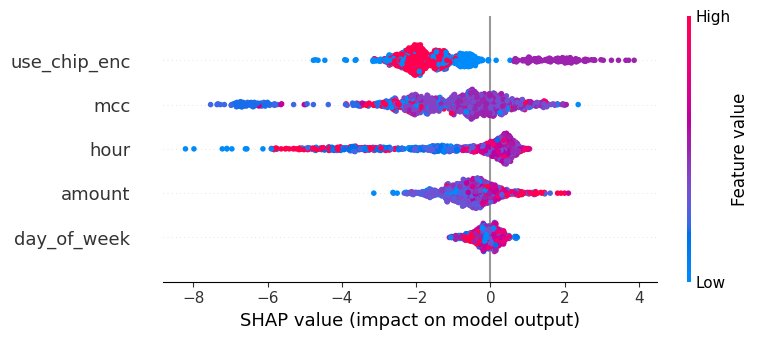

In [16]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test[:1000])

# Create the plot without displaying it immediately
shap.summary_plot(shap_values, X_test[:1000], max_display=5, show=False)

# Save to Google Drive
plt.savefig(
    "/content/drive/MyDrive/fintech/reports/shap_summary_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [12]:
# XGBoost contributes 0-40 points
xgb_prob_all = xgb.predict_proba(X[model_features].fillna(0))[:, 1]
df['xgb_score'] = xgb_prob_all * 40

# Final score = rule + isolation forest + xgboost (max 100)
df['fraud_score'] = (
    df['rule_score'].clip(0, 20) +
    df['iso_score'].clip(0, 40) +
    df['xgb_score'].clip(0, 40)
).clip(0, 100)

# Risk label
def risk_label(score):
    if score <= 30:
        return 'Low'
    elif score <= 60:
        return 'Medium'
    else:
        return 'High'

df['risk_level'] = df['fraud_score'].apply(risk_label)
print(df['risk_level'].value_counts())

risk_level
Low       7756871
Medium    1043937
High       114155
Name: count, dtype: int64


In [13]:
df[[
    'transaction_id', 'client_id', 'amount', 'is_fraud',
    'rule_score', 'iso_score', 'xgb_score',
    'fraud_score', 'risk_level'
]].to_csv('/content/drive/MyDrive/fintech/processed/fraud_scores.csv', index=False)